# RFM Customer Segmentation

Segment customers with completed orders using Recency, Frequency, and Monetary value.

In [62]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    pairwise_distances,
    silhouette_samples,
)
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.db_utils import get_engine, read_sql

RFM_COLUMNS = ["recency", "frequency", "monetary"]
LOG_COLUMNS = ["frequency", "monetary"]
K_VALUES = range(2, 11)

## Data Preparation

In [37]:
engine = get_engine()
customer_rfm = read_sql(
    engine,
    """
    SELECT
        total_orders AS frequency,
        total_revenue AS monetary,
        days_since_last_purchase AS recency
    FROM marts.mart_customer
    WHERE total_orders > 0
      AND days_since_last_purchase IS NOT NULL
    """,
)
customer_rfm[RFM_COLUMNS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
recency,86691.0,1307.55,1028.55,0.00,367.00,1097.00,2037.0,3832.00
frequency,86691.0,6.38,7.49,1.00,1.00,3.00,8.0,97.00
monetary,86691.0,154388.74,190532.28,445.65,29329.52,82588.62,208263.7,3244730.02


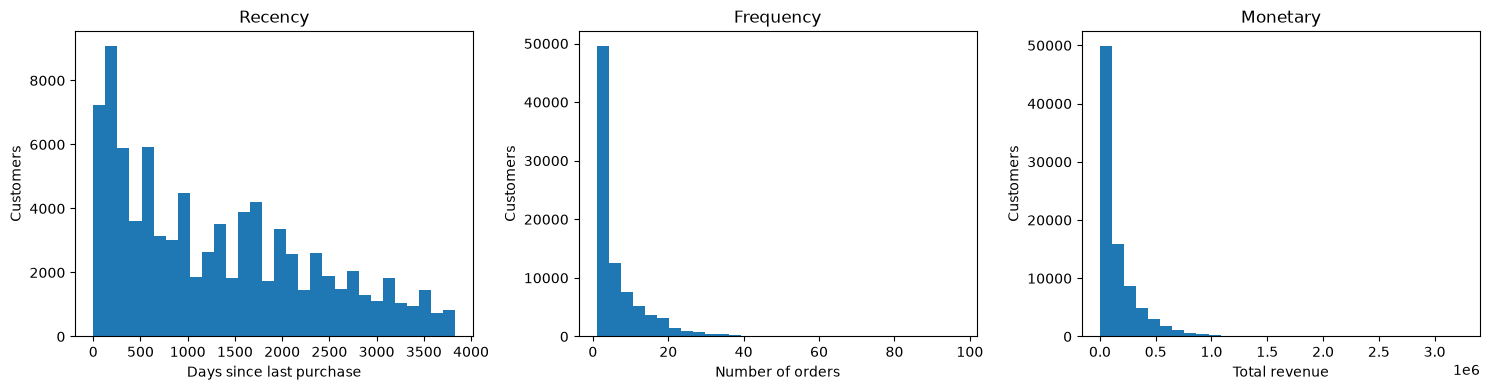

In [38]:
metric_labels = {
    "recency": ("Recency", "Days since last purchase"),
    "frequency": ("Frequency", "Number of orders"),
    "monetary": ("Monetary", "Total revenue"),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, RFM_COLUMNS):
    title, xlabel = metric_labels[metric]
    ax.hist(customer_rfm[metric].dropna(), bins=30)
    ax.set(title=title, xlabel=xlabel, ylabel="Customers")
plt.tight_layout()
plt.show()

In [39]:
def build_rfm_diagnostics(dataframe, columns):
    rows = []
    for column in columns:
        values = dataframe[column].dropna()
        q1, median, q3 = values.quantile([0.25, 0.50, 0.75])
        mean = values.mean()
        std = values.std()
        iqr = q3 - q1
        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr
        is_outlier = values.lt(lower_fence) | values.gt(upper_fence)
        rows.append({
            "variable": column,
            "count": values.size,
            "missing_pct": dataframe[column].isna().mean() * 100,
            "mean": mean,
            "median": median,
            "std": std,
            "cv": std / mean if mean else np.nan,
            "min": values.min(),
            "p01": values.quantile(0.01),
            "q1": q1,
            "p95": values.quantile(0.95),
            "p99": values.quantile(0.99),
            "max": values.max(),
            "skewness": values.skew(),
            "excess_kurtosis": values.kurt(),
            "iqr_lower_fence": lower_fence,
            "iqr_upper_fence": upper_fence,
            "iqr_outlier_count": int(is_outlier.sum()),
            "iqr_outlier_pct": is_outlier.mean() * 100,
            "zero_pct": values.eq(0).mean() * 100,
        })
    return pd.DataFrame(rows).set_index("variable")

rfm_diagnostics = build_rfm_diagnostics(customer_rfm, RFM_COLUMNS)
rfm_diagnostics.round(3)

,count,missing_pct,mean,median,std,cv,min,p01,q1,p95,p99,max,skewness,excess_kurtosis,iqr_lower_fence,iqr_upper_fence,iqr_outlier_count,iqr_outlier_pct,zero_pct
variable,,,,,,,,,,,,,,,,,,,
recency,86691,0.0,1307.551,1097.00,1028.550,0.787,0.00,10.000,367.000,3280.00,3699.00,3832.00,0.601,-0.708,-2138.000,4542.000,0,0.000,0.078
frequency,86691,0.0,6.377,3.00,7.485,1.174,1.00,1.000,1.000,21.00,35.00,97.00,2.605,10.106,-9.500,18.500,6185,7.135,0.000
monetary,86691,0.0,154388.745,82588.62,190532.283,1.234,445.65,2047.738,29329.515,543581.38,881879.66,3244730.02,2.541,10.345,-239071.762,476664.978,5937,6.848,0.000


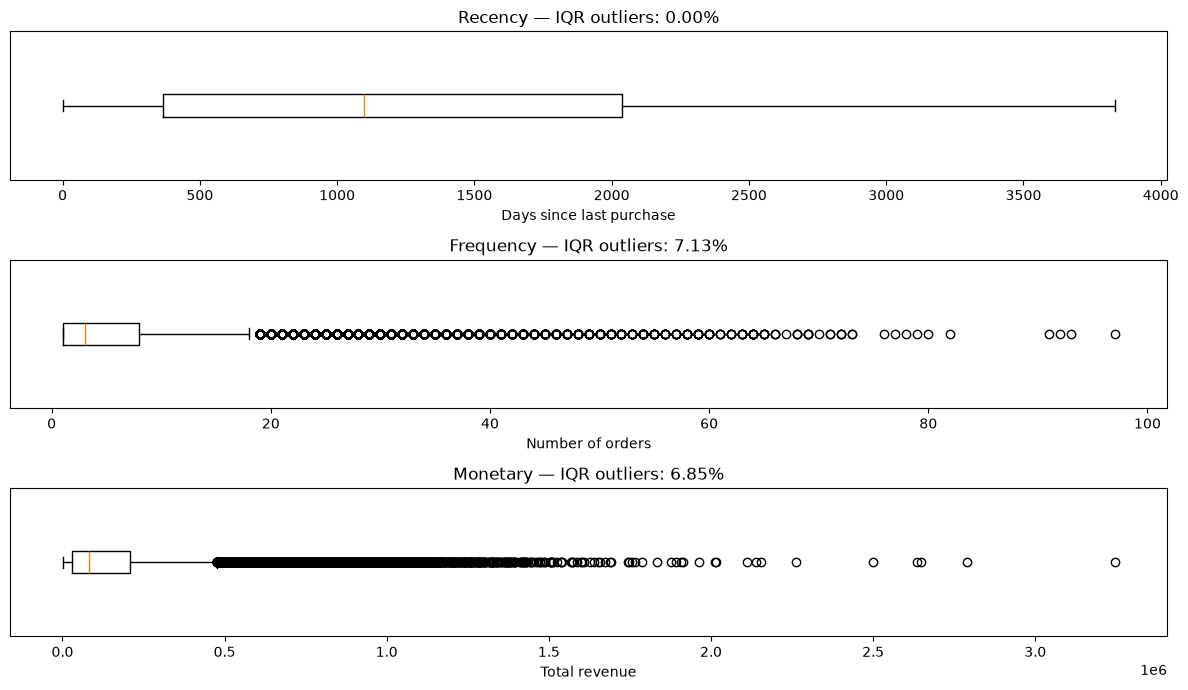

In [40]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7))
for ax, metric in zip(axes, RFM_COLUMNS):
    title, xlabel = metric_labels[metric]
    outlier_pct = rfm_diagnostics.loc[metric, "iqr_outlier_pct"]
    ax.boxplot(customer_rfm[metric].dropna(), orientation="horizontal")
    ax.set(title=f"{title} — IQR outliers: {outlier_pct:.2f}%", xlabel=xlabel, yticks=[])
plt.tight_layout()
plt.show()

## RFM Transformation

Keep Recency unchanged and apply `log1p` to Frequency and Monetary.

In [41]:
rfm_processed = customer_rfm[RFM_COLUMNS].copy()
rfm_processed[LOG_COLUMNS] = np.log1p(rfm_processed[LOG_COLUMNS])

skewness_comparison = pd.DataFrame({
    "skewness_before": customer_rfm[RFM_COLUMNS].skew(),
    "skewness_after": rfm_processed.skew(),
    "treatment": ["Unchanged", "log1p", "log1p"],
})
skewness_comparison.round(3)

,skewness_before,skewness_after,treatment
recency,0.601,0.601,Unchanged
frequency,2.605,0.543,log1p
monetary,2.541,-0.479,log1p


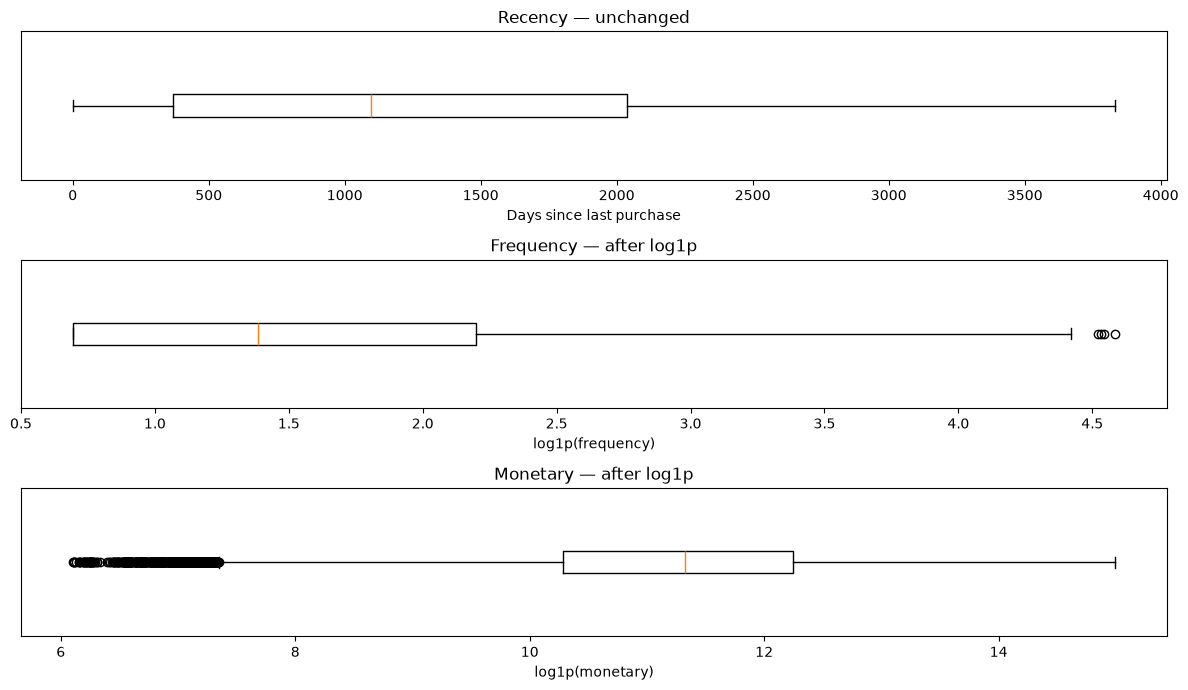

In [42]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7))
for ax, metric in zip(axes, RFM_COLUMNS):
    title, xlabel = metric_labels[metric]
    treatment = "after log1p" if metric in LOG_COLUMNS else "unchanged"
    xlabel = f"log1p({metric})" if metric in LOG_COLUMNS else xlabel
    ax.boxplot(rfm_processed[metric].dropna(), orientation="horizontal")
    ax.set(title=f"{title} — {treatment}", xlabel=xlabel, yticks=[])
plt.tight_layout()
plt.show()

## Scaling

In [43]:
if rfm_processed.isna().any().any():
    raise ValueError("RFM data contains missing values.")

scaler = StandardScaler()
rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_processed),
    columns=RFM_COLUMNS,
    index=customer_rfm.index,
)
rfm_scaled.agg(["mean", "std", "min", "max"]).T.round(3)

,mean,std,min,max
recency,-0.0,1.0,-1.271,2.454
frequency,0.0,1.0,-1.145,3.606
monetary,-0.0,1.0,-3.647,2.732


## K Selection

Evaluate K-Means for `k=2–10` with `n_init=20` and `random_state=42`. Silhouette scores use the same fixed sample of up to 5,000 customers; all other metrics use the full dataset.

In [44]:
silhouette_sample = rfm_scaled.sample(n=min(5_000, len(rfm_scaled)), random_state=42)
models_by_k = {}
labels_by_k = {}
silhouette_by_k = {}
evaluation_rows = []

for k in K_VALUES:
    model = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = model.fit_predict(rfm_scaled)
    cluster_sizes = pd.Series(labels).value_counts()
    sample_labels = pd.Series(labels, index=rfm_scaled.index).loc[silhouette_sample.index].to_numpy()
    sample_silhouette = silhouette_samples(silhouette_sample, sample_labels)
    models_by_k[k] = model
    labels_by_k[k] = labels
    silhouette_by_k[k] = pd.DataFrame(
        {"cluster": sample_labels, "silhouette": sample_silhouette},
        index=silhouette_sample.index,
    )
    evaluation_rows.append({
        "k": k,
        "inertia_wcss": model.inertia_,
        "silhouette_score": sample_silhouette.mean(),
        "davies_bouldin": davies_bouldin_score(rfm_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(rfm_scaled, labels),
        "smallest_cluster_count": int(cluster_sizes.min()),
        "smallest_cluster_pct": cluster_sizes.min() / len(labels) * 100,
        "largest_cluster_pct": cluster_sizes.max() / len(labels) * 100,
    })

k_evaluation = pd.DataFrame(evaluation_rows).set_index("k")
metric_format = {
    "inertia_wcss": "{:,.2f}",
    "silhouette_score": "{:.4f}",
    "davies_bouldin": "{:.4f}",
    "calinski_harabasz": "{:,.2f}",
    "smallest_cluster_count": "{:,.0f}",
    "smallest_cluster_pct": "{:.2f}%",
    "largest_cluster_pct": "{:.2f}%",
}
k_evaluation.style.format(metric_format)

,inertia_wcss,silhouette_score,davies_bouldin,calinski_harabasz,smallest_cluster_count,smallest_cluster_pct,largest_cluster_pct
k,,,,,,,
2,"110,595.52",0.4692,0.7816,"117,166.90","43,269",49.91%,50.09%
3,"75,408.09",0.3852,0.9280,"106,144.89","25,921",29.90%,37.81%
4,"61,317.26",0.3415,1.0344,"93,665.64","18,942",21.85%,30.73%
5,"49,570.98",0.3425,0.9568,"92,028.84","12,961",14.95%,27.14%
6,"42,800.31",0.3316,0.9822,"88,012.13","9,050",10.44%,22.28%
7,"37,041.89",0.3170,0.9378,"86,989.27","7,505",8.66%,21.57%
8,"32,941.21",0.3186,0.9333,"85,385.26","6,577",7.59%,19.65%
9,"29,838.19",0.3033,0.9495,"83,607.48","5,759",6.64%,16.63%
10,"27,278.62",0.3088,0.9365,"82,194.60","4,566",5.27%,14.67%


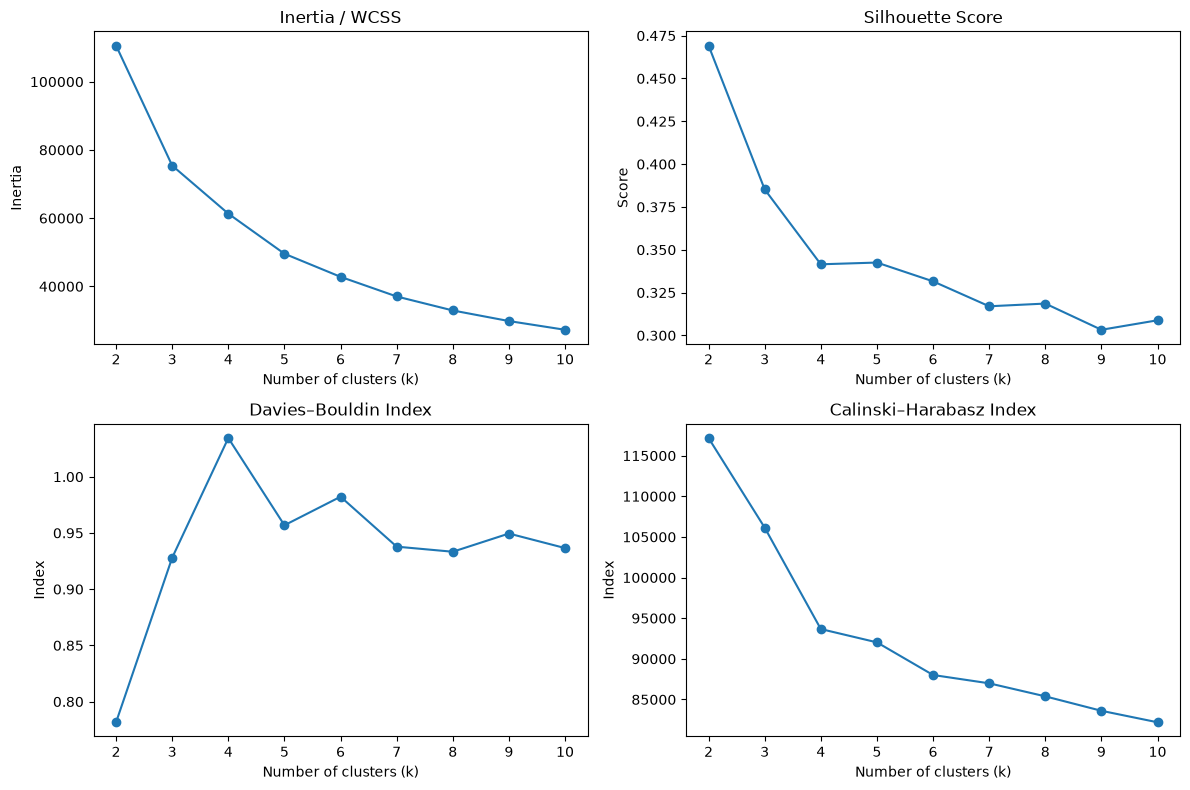

In [45]:
metric_plots = [
    ("inertia_wcss", "Inertia / WCSS", "Inertia"),
    ("silhouette_score", "Silhouette Score", "Score"),
    ("davies_bouldin", "Davies–Bouldin Index", "Index"),
    ("calinski_harabasz", "Calinski–Harabasz Index", "Index"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (column, title, ylabel) in zip(axes.flat, metric_plots):
    ax.plot(k_evaluation.index, k_evaluation[column], marker="o")
    ax.set(title=title, xlabel="Number of clusters (k)", ylabel=ylabel, xticks=list(K_VALUES))
plt.tight_layout()
plt.show()

## Cluster Evaluation

Compare and profile clusters for `k=2–5`.

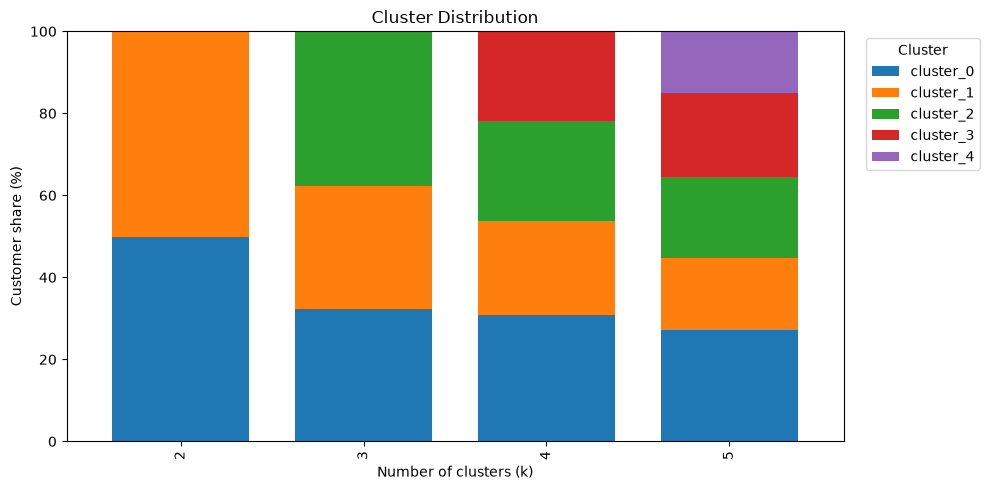

,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4
k,,,,,
2,49.91,50.09,0.00,0.00,0.00
3,32.28,29.90,37.81,0.00,0.00
4,30.73,22.94,24.48,21.85,0.00
5,27.14,17.53,19.83,20.54,14.95


In [54]:
CLUSTER_K_VALUES = range(2, 6)

cluster_share_by_k = pd.DataFrame({
    k: pd.Series(labels_by_k[k]).value_counts(normalize=True).sort_index() * 100
    for k in CLUSTER_K_VALUES
}).T.fillna(0)
cluster_share_by_k.index.name = "k"
cluster_share_by_k.columns = [f"cluster_{cluster}" for cluster in cluster_share_by_k.columns]

ax = cluster_share_by_k.plot(kind="bar", stacked=True, figsize=(10, 5), width=0.75)
ax.set(title="Cluster Distribution", xlabel="Number of clusters (k)", ylabel="Customer share (%)")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

cluster_share_by_k.round(2)

In [55]:
def summarize_cluster_silhouette(silhouette_frame):
    return silhouette_frame.groupby("cluster")["silhouette"].agg(
        silhouette_mean="mean",
        silhouette_median="median",
        silhouette_min="min",
        negative_silhouette_pct=lambda values: values.lt(0).mean() * 100,
        sample_customer_count="size",
    ).reset_index()

silhouette_summary_by_k = {
    k: summarize_cluster_silhouette(silhouette_by_k[k])
    for k in CLUSTER_K_VALUES
}
silhouette_format = {
    "silhouette_mean": "{:.4f}",
    "silhouette_median": "{:.4f}",
    "silhouette_min": "{:.4f}",
    "negative_silhouette_pct": "{:.2f}%",
    "sample_customer_count": "{:,.0f}",
}

for k, summary in silhouette_summary_by_k.items():
    display(summary.style.format(silhouette_format).set_caption(f"Cluster Silhouette — k={k}"))

,cluster,silhouette_mean,silhouette_median,silhouette_min,negative_silhouette_pct,sample_customer_count
0,0,0.4082,0.4836,-0.0918,4.36%,"2,455"
1,1,0.5281,0.5944,0.0606,0.00%,"2,545"


,cluster,silhouette_mean,silhouette_median,silhouette_min,negative_silhouette_pct,sample_customer_count
0,0,0.5027,0.5709,0.0279,0.00%,"1,625"
1,1,0.3818,0.4354,-0.0269,1.29%,"1,477"
2,2,0.2873,0.3085,-0.1089,4.16%,"1,898"


,cluster,silhouette_mean,silhouette_median,silhouette_min,negative_silhouette_pct,sample_customer_count
0,0,0.2811,0.2948,-0.1006,3.57%,"1,597"
1,1,0.3510,0.3851,-0.0387,1.59%,"1,129"
2,2,0.4937,0.5525,0.0313,0.00%,"1,205"
3,3,0.2502,0.2677,-0.0423,2.71%,"1,069"


,cluster,silhouette_mean,silhouette_median,silhouette_min,negative_silhouette_pct,sample_customer_count
0,0,0.3109,0.3366,-0.0978,3.71%,"1,402"
1,1,0.3404,0.3807,-0.0529,2.77%,904
2,2,0.3018,0.3067,-0.0002,0.11%,917
3,3,0.4795,0.5408,0.0232,0.00%,"1,022"
4,4,0.2678,0.2885,-0.0737,9.01%,755


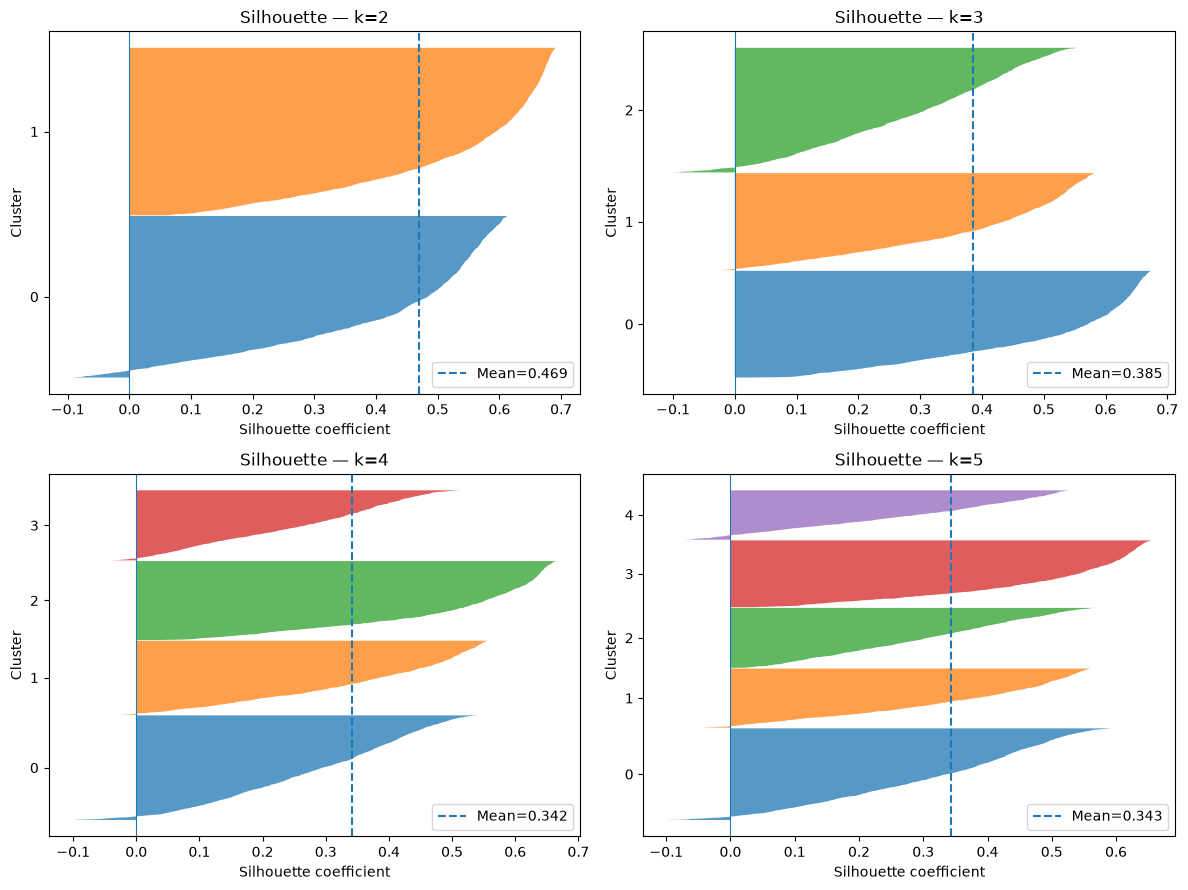

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, k in zip(axes.flat, CLUSTER_K_VALUES):
    silhouette_frame = silhouette_by_k[k]
    average_score = silhouette_frame["silhouette"].mean()
    y_lower = 10
    y_ticks = []
    y_labels = []
    for cluster in sorted(silhouette_frame["cluster"].unique()):
        values = np.sort(silhouette_frame.loc[silhouette_frame["cluster"] == cluster, "silhouette"])
        y_upper = y_lower + len(values)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, values, alpha=0.75)
        y_ticks.append((y_lower + y_upper) / 2)
        y_labels.append(str(cluster))
        y_lower = y_upper + 10
    ax.axvline(average_score, linestyle="--", label=f"Mean={average_score:.3f}")
    ax.axvline(0, linewidth=0.8)
    ax.set(title=f"Silhouette — k={k}", xlabel="Silhouette coefficient", ylabel="Cluster")
    ax.set_yticks(y_ticks, y_labels)
    ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Cluster Profiling

Interpret clusters using the original RFM values.

In [57]:
def build_cluster_profile(raw_rfm, labels):
    profiled = raw_rfm[RFM_COLUMNS].copy()
    profiled["cluster"] = labels
    profile = profiled.groupby("cluster").agg(
        customer_count=("cluster", "size"),
        mean_recency=("recency", "mean"),
        median_recency=("recency", "median"),
        mean_frequency=("frequency", "mean"),
        median_frequency=("frequency", "median"),
        mean_monetary=("monetary", "mean"),
        median_monetary=("monetary", "median"),
        total_monetary=("monetary", "sum"),
    ).reset_index()
    profile.insert(2, "customer_pct", profile["customer_count"] / len(profiled) * 100)
    profile["monetary_share_pct"] = profile["total_monetary"] / profiled["monetary"].sum() * 100
    return profile

profiles_by_k = {k: build_cluster_profile(customer_rfm, labels_by_k[k]) for k in CLUSTER_K_VALUES}
profile_format = {
    "customer_count": "{:,.0f}", "customer_pct": "{:.2f}%",
    "mean_recency": "{:,.1f}", "median_recency": "{:,.1f}",
    "mean_frequency": "{:,.2f}", "median_frequency": "{:,.1f}",
    "mean_monetary": "{:,.2f}", "median_monetary": "{:,.2f}",
    "total_monetary": "{:,.2f}", "monetary_share_pct": "{:.2f}%",
}

for k, profile in profiles_by_k.items():
    display(profile.style.format(profile_format).set_caption(f"Original RFM Profile — k={k}"))

,cluster,customer_count,customer_pct,mean_recency,median_recency,mean_frequency,median_frequency,mean_monetary,median_monetary,total_monetary,monetary_share_pct
0,0,"43,269",49.91%,"2,024.5","2,022.0",1.79,1.0,"37,733.99","29,357.14","1,632,711,905.78",12.20%
1,1,"43,422",50.09%,593.1,461.0,10.95,8.0,"270,632.46","207,749.56","11,751,402,767.01",87.80%


,cluster,customer_count,customer_pct,mean_recency,median_recency,mean_frequency,median_frequency,mean_monetary,median_monetary,total_monetary,monetary_share_pct
0,0,"27,988",32.28%,468.3,303.0,14.43,12.0,"357,677.74","296,476.45","10,010,684,520.36",74.80%
1,1,"25,921",29.90%,"2,529.0","2,502.0",1.37,1.0,"25,429.09","18,396.91","659,147,336.52",4.92%
2,2,"32,782",37.81%,"1,058.3","1,003.0",3.46,3.0,"82,797.96","75,589.94","2,714,282,815.91",20.28%


,cluster,customer_count,customer_pct,mean_recency,median_recency,mean_frequency,median_frequency,mean_monetary,median_monetary,total_monetary,monetary_share_pct
0,0,"26,638",30.73%,971.8,907.5,5.22,5.0,"128,725.18","118,376.27","3,428,981,446.29",25.62%
1,1,"19,887",22.94%,"2,810.3","2,770.0",1.39,1.0,"27,436.41","19,132.80","545,627,863.20",4.08%
2,2,"21,224",24.48%,391.1,264.0,16.63,14.0,"412,092.20","353,407.16","8,746,244,940.86",65.35%
3,3,"18,942",21.85%,"1,228.8","1,337.5",1.75,2.0,"35,015.33","31,552.88","663,260,422.44",4.96%


,cluster,customer_count,customer_pct,mean_recency,median_recency,mean_frequency,median_frequency,mean_monetary,median_monetary,total_monetary,monetary_share_pct
0,0,"23,532",27.14%,712.5,619.0,6.14,6.0,"150,878.33","142,226.95","3,550,468,748.28",26.53%
1,1,"15,196",17.53%,"2,841.8","2,844.0",1.15,1.0,"15,926.31","12,037.65","242,016,133.31",1.81%
2,2,"17,195",19.83%,"2,060.7","2,011.0",2.72,2.0,"69,770.88","61,847.35","1,199,710,325.30",8.96%
3,3,"17,807",20.54%,380.2,256.0,18.10,16.0,"448,713.82","391,155.80","7,990,247,031.49",59.70%
4,4,"12,961",14.95%,864.0,883.0,1.69,2.0,"30,990.85","25,989.55","401,672,434.41",3.00%


In [58]:
overall_mean_monetary = customer_rfm["monetary"].mean()
diagnostic_rows = []
closest_pair_rows = []

for k in CLUSTER_K_VALUES:
    for _, row in profiles_by_k[k].iterrows():
        diagnostic_rows.append({
            "k": k,
            "cluster": int(row["cluster"]),
            "customer_pct": row["customer_pct"],
            "monetary_share_pct": row["monetary_share_pct"],
            "mean_monetary_vs_overall": row["mean_monetary"] / overall_mean_monetary,
            "is_small_below_5pct": row["customer_pct"] < 5,
            "is_extreme_monetary_3x": row["mean_monetary"] >= 3 * overall_mean_monetary,
        })
    distances = pairwise_distances(models_by_k[k].cluster_centers_)
    np.fill_diagonal(distances, np.inf)
    cluster_a, cluster_b = np.unravel_index(np.argmin(distances), distances.shape)
    closest_pair_rows.append({
        "k": k,
        "closest_cluster_a": cluster_a,
        "closest_cluster_b": cluster_b,
        "centroid_distance_scaled": distances[cluster_a, cluster_b],
    })

cluster_diagnostics = pd.DataFrame(diagnostic_rows)
closest_cluster_pairs = pd.DataFrame(closest_pair_rows)
display(cluster_diagnostics.round(3))
display(closest_cluster_pairs.round(3))

,k,cluster,customer_pct,monetary_share_pct,mean_monetary_vs_overall,is_small_below_5pct,is_extreme_monetary_3x
0,2,0,49.912,12.199,0.244,False,False
1,2,1,50.088,87.801,1.753,False,False
2,3,0,32.285,74.795,2.317,False,False
3,3,1,29.900,4.925,0.165,False,False
4,3,2,37.815,20.280,0.536,False,False
5,4,0,30.728,25.620,0.834,False,False
6,4,1,22.940,4.077,0.178,False,False
7,4,2,24.482,65.348,2.669,False,False
8,4,3,21.850,4.956,0.227,False,False
9,5,0,27.145,26.527,0.977,False,False


,k,closest_cluster_a,closest_cluster_b,centroid_distance_scaled
0,2,0,1,2.626
1,3,1,2,1.890
2,4,0,3,1.467
3,5,2,4,1.403


In [59]:
for previous_k, next_k in zip(range(2, 5), range(3, 6)):
    transition = pd.crosstab(
        pd.Series(labels_by_k[previous_k], name=f"cluster_k{previous_k}"),
        pd.Series(labels_by_k[next_k], name=f"cluster_k{next_k}"),
        normalize="index",
    ) * 100
    display(transition.style.format("{:.2f}%").set_caption(
        f"Cluster transitions from k={previous_k} to k={next_k}"
    ))

cluster_k3,0,1,2
cluster_k2,,,
0,0.00%,59.91%,40.09%
1,64.46%,0.00%,35.54%


cluster_k4,0,1,2,3
cluster_k3,,,,
0,24.17%,0.00%,75.83%,0.00%
1,0.00%,75.97%,0.00%,24.03%
2,60.62%,0.59%,0.00%,38.78%


cluster_k5,0,1,2,3,4
cluster_k4,,,,,
0,75.51%,0.00%,20.58%,0.00%,3.90%
1,0.00%,72.99%,27.01%,0.00%,0.00%
2,16.10%,0.00%,0.00%,83.90%,0.00%
3,0.00%,3.59%,33.48%,0.00%,62.93%


## Stability

Compare `k=2` and `k=3` across 20 random states using the Adjusted Rand Index.

In [60]:
CANDIDATE_K = [2, 3]
RANDOM_STATES = range(20)
stability_rows = []

for k in CANDIDATE_K:
    runs = [
        KMeans(n_clusters=k, n_init=20, random_state=seed).fit_predict(rfm_scaled)
        for seed in RANDOM_STATES
    ]
    pairwise_ari = [
        adjusted_rand_score(runs[i], runs[j])
        for i in range(len(runs))
        for j in range(i + 1, len(runs))
    ]
    stability_rows.append({
        "k": k,
        "runs": len(runs),
        "ari_pair_count": len(pairwise_ari),
        "ari_mean": np.mean(pairwise_ari),
        "ari_median": np.median(pairwise_ari),
        "ari_min": np.min(pairwise_ari),
        "ari_std": np.std(pairwise_ari, ddof=1),
    })

stability_summary = pd.DataFrame(stability_rows).set_index("k")
stability_summary.style.format({
    "runs": "{:,.0f}", "ari_pair_count": "{:,.0f}",
    "ari_mean": "{:.4f}", "ari_median": "{:.4f}",
    "ari_min": "{:.4f}", "ari_std": "{:.4f}",
})

,runs,ari_pair_count,ari_mean,ari_median,ari_min,ari_std
k,,,,,,
2,20,190,0.9974,0.9979,0.9940,0.0023
3,20,190,0.9887,0.9902,0.9649,0.0074


## Conclusion

**Select `k=3`.**

- `k=2` performs best geometrically: Silhouette 0.4692, Davies–Bouldin 0.7816, and Calinski–Harabasz 117,166.90. The elbow drops sharply from `k=2` to `k=3`, then levels off.
- `k=3` creates three actionable groups: high-value/recent customers (32.28% of customers; 74.80% of Monetary), inactive/low-value customers (29.90%; 4.92%), and mid-value customers (37.81%; 20.28%).
- Mean cluster-level Silhouette scores for `k=3` are 0.503, 0.382, and 0.287. Negative Silhouette shares are 0%, 1.29%, and 4.16%.
- `k=3` remains stable, with a mean ARI of 0.9887 and a minimum of 0.9649. `k=2` reaches 0.9974 and 0.9940 but produces two overly broad groups.
- `k=4–5` mainly subdivides existing clusters. The nearest-centroid distance falls from 1.890 at `k=3` to 1.467 and 1.403 without improving Silhouette quality.
- No cluster contains less than 5% of customers or has mean Monetary above three times the overall mean. Mean Monetary remains above the median in high-value clusters because of right-skewed tails.

## Cluster Labels

- Cluster 1: **Low-Value Customers**
- Cluster 2: **Mid-Value Customers**
- Cluster 0: **High-Value Customers**

## PCA Visualization

Project the scaled RFM data onto two principal components to visualize the selected three-cluster solution.

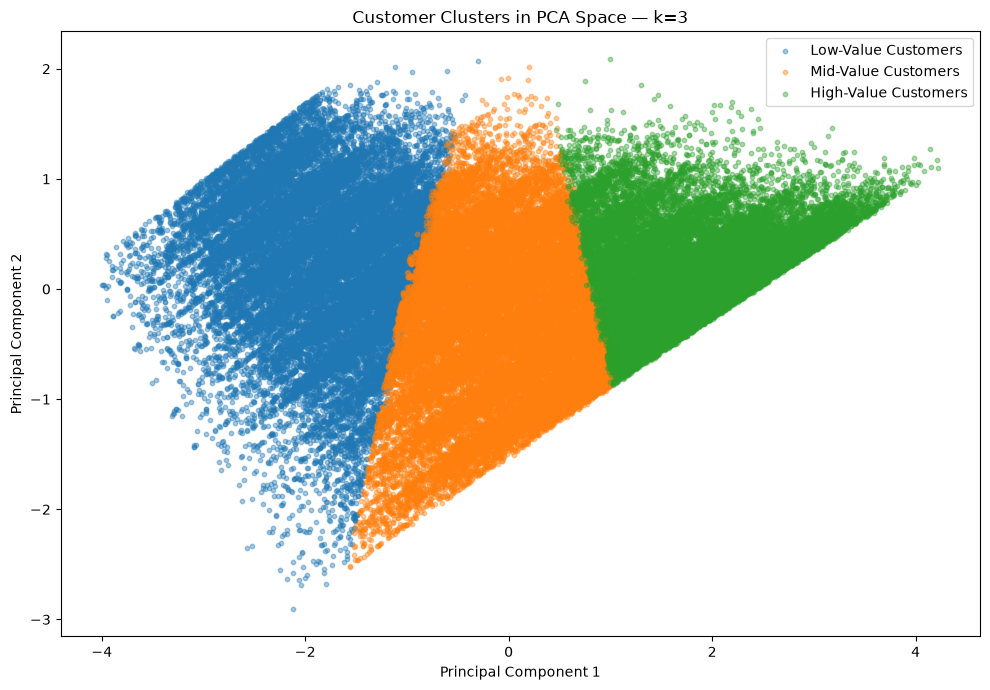

In [64]:
pca_coordinates = PCA(n_components=2).fit_transform(rfm_scaled)
selected_labels = labels_by_k[3]
cluster_names = {
    1: "Low-Value Customers",
    2: "Mid-Value Customers",
    0: "High-Value Customers",
}

plt.figure(figsize=(10, 7))
for cluster, cluster_name in cluster_names.items():
    cluster_mask = selected_labels == cluster
    plt.scatter(
        pca_coordinates[cluster_mask, 0],
        pca_coordinates[cluster_mask, 1],
        s=10,
        alpha=0.4,
        label=cluster_name,
    )
plt.title("Customer Clusters in PCA Space — k=3")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()